# Tutorial: From Qiskit 2.0 Scheduled Circuit to Frame-Tracked I/Q Waveforms

This tutorial demonstrates the complete workflow of `qiskit-waveform-sim`:

1. Create and schedule a quantum circuit using Qiskit 2.0
2. Compile the waveform simulator with exact Virtual-Z frame tracking
3. Extract sample-precise I/Q waveforms using lazy windowed evaluation
4. Visualize with interactive Pulse Sheet and I/Q Oscilloscope

In [46]:
# Install if needed
# %pip install qiskit-waveform-sim -q

import numpy as np
from qiskit import QuantumCircuit
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.transpiler import generate_preset_pass_manager

from qiskit_waveform_sim import TargetWaveformSimulator
from qiskit_waveform_sim.visualization import (
    create_combined_view,
    show_iq_oscilloscope,
    show_pulse_sheet,
)

## 1. Create Backend and Circuit

In [47]:
# 2-qubit generic backend (emulates IBM Eagle/Heron architecture)
backend = GenericBackendV2(num_qubits=2, seed=42)

print(f"Backend dt: {backend.target.dt:.3e} s")
print(f"Backend dt (ns): {backend.target.dt * 1e9:.3f} ns")
print(f"Qubits: {backend.target.num_qubits}")
print(f"Basis gates: {list(backend.target.operation_names)[:10]}...")

Backend dt: 2.220e-10 s
Backend dt (ns): 0.222 ns
Qubits: 2
Basis gates: ['cx', 'id', 'rz', 'sx', 'x', 'reset', 'delay', 'measure']...


In [48]:
'''# Example 1:- Create a circuit with standard gates.
qc = QuantumCircuit(2, 2)
qc.h(0)                    # Hadamard = rz(Ï€/2) -> sx -> rz(Ï€/2)
qc.cx(0, 1)                # CNOT gate
qc.rx(np.pi/4, 0)          # Fractional RX(Ï€/4)
qc.rzz(np.pi/2, 0, 1)      # Fractional RZZ(Ï€/2)
qc.measure([0, 1], [0, 1])

print(f"Circuit depth: {qc.depth()}")
print(f"Operations: {qc.count_ops()}")
qc.draw('mpl')'''

'# Example 1:- Create a circuit with standard gates.\nqc = QuantumCircuit(2, 2)\nqc.h(0)                    # Hadamard = rz(Ï€/2) -> sx -> rz(Ï€/2)\nqc.cx(0, 1)                # CNOT gate\nqc.rx(np.pi/4, 0)          # Fractional RX(Ï€/4)\nqc.rzz(np.pi/2, 0, 1)      # Fractional RZZ(Ï€/2)\nqc.measure([0, 1], [0, 1])\n\nprint(f"Circuit depth: {qc.depth()}")\nprint(f"Operations: {qc.count_ops()}")\nqc.draw(\'mpl\')'

Circuit depth: 9
Operations: OrderedDict({'x': 1, 'h': 1, 't': 1, 's': 1, 'y': 1, 'tdg': 1, 'sx': 1, 'u': 1, 'measure': 1})


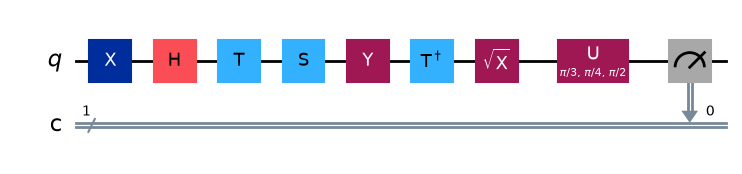

In [49]:
# Example 2:- 1-qubit deep sequential circuit
qc1 = QuantumCircuit(1, 1)
qc1.x(0)                           # Pauli-X (bit flip)
qc1.h(0)                           # Hadamard superposition
qc1.t(0)                           # T gate (pi/4 phase rotation)
qc1.s(0)                           # S gate (pi/2 phase rotation)
qc1.y(0)                           # Pauli-Y gate
qc1.tdg(0)                         # T-dagger (inverse T gate)
qc1.sx(0)                          # Square-root of X gate
qc1.u(np.pi/3, np.pi/4, np.pi/2, 0)# General 3-angle U(theta, phi, lam) gate
qc1.measure(0, 0)

print(f"Circuit depth: {qc1.depth()}")
print(f"Operations: {qc1.count_ops()}")
qc1.draw('mpl')

In [50]:
'''# Example 3:- 3-qubit circuit with phase and multi-controlled gates
qc2 = QuantumCircuit(3, 3)
qc2.h(0)                           # Superposition on qubit 0
qc2.cx(0, 1)                       # Entangle q0 and q1
qc2.cx(1, 2)                       # Entangle q1 and q2 (creates GHZ state)
qc2.s(0)                           # S phase gate (runs in parallel with cx above)
qc2.sdg(1)                         # S-dagger gate on q1
qc2.cz(0, 2)                       # Controlled-Z between q0 and q2
qc2.ccx(0, 1, 2)                   # Toffoli (CCNOT) gate controlled by q0, q1
qc2.measure([0, 1, 2], [0, 1, 2])

print(f"Circuit depth: {qc2.depth()}")
print(f"Operations: {qc2.count_ops()}")
qc2.draw('mpl')'''

'# Example 3:- 3-qubit circuit with phase and multi-controlled gates\nqc2 = QuantumCircuit(3, 3)\nqc2.h(0)                           # Superposition on qubit 0\nqc2.cx(0, 1)                       # Entangle q0 and q1\nqc2.cx(1, 2)                       # Entangle q1 and q2 (creates GHZ state)\nqc2.s(0)                           # S phase gate (runs in parallel with cx above)\nqc2.sdg(1)                         # S-dagger gate on q1\nqc2.cz(0, 2)                       # Controlled-Z between q0 and q2\nqc2.ccx(0, 1, 2)                   # Toffoli (CCNOT) gate controlled by q0, q1\nqc2.measure([0, 1, 2], [0, 1, 2])\n\nprint(f"Circuit depth: {qc2.depth()}")\nprint(f"Operations: {qc2.count_ops()}")\nqc2.draw(\'mpl\')'

## 2. Transpile and Schedule (ALAP)

In [58]:
from numpy._typing import _nested_sequence
# Transpile to backend basis and schedule with ALAP
pm = generate_preset_pass_manager(
    optimization_level=1,
    backend=backend,
    scheduling_method="alap"
)
scheduled_qc = pm.run(qc)

print(f"Scheduled circuit depth: {scheduled_qc.depth()}")
print(f"Total duration: {scheduled_qc.op_start_times[-1] if scheduled_qc.op_start_times else 0} dt")
print(f"Total duration: {scheduled_qc.op_start_times[-1] * backend.target.dt * 1e9:.1f} ns")

# Show scheduling info
for inst, start_dt in zip(scheduled_qc.data, scheduled_qc.op_start_times):
    op = inst.operation
    print(f"  {start_dt:4d} dt: {op.name} {inst.qubits}")

Scheduled circuit depth: 14
Total duration: 10794 dt
Total duration: 2396.3 ns
     0 dt: rz (<Qubit register=(2, "q"), index=0>,)
     0 dt: sx (<Qubit register=(2, "q"), index=0>,)
   195 dt: rz (<Qubit register=(2, "q"), index=0>,)
     0 dt: delay (<Qubit register=(2, "q"), index=1>,)
   195 dt: cx (<Qubit register=(2, "q"), index=0>, <Qubit register=(2, "q"), index=1>)
  3367 dt: rz (<Qubit register=(2, "q"), index=0>,)
  3367 dt: sx (<Qubit register=(2, "q"), index=0>,)
  3562 dt: rz (<Qubit register=(2, "q"), index=0>,)
  3562 dt: sx (<Qubit register=(2, "q"), index=0>,)
  3757 dt: rz (<Qubit register=(2, "q"), index=0>,)
  3367 dt: delay (<Qubit register=(2, "q"), index=1>,)
  3757 dt: cx (<Qubit register=(2, "q"), index=0>, <Qubit register=(2, "q"), index=1>)
  6929 dt: rz (<Qubit register=(2, "q"), index=1>,)
  6929 dt: cx (<Qubit register=(2, "q"), index=0>, <Qubit register=(2, "q"), index=1>)
  10101 dt: delay (<Qubit register=(2, "q"), index=1>,)
  10101 dt: measure (<Qubi

## 3. Compile Waveform Simulator

In [52]:
# Compile with frame tracking
sim = TargetWaveformSimulator(backend.target).compile(scheduled_qc)

print(f"Total circuit duration: {sim.total_duration_dt} dt")
print(f"Channels with events: {sim.get_channels()}")

# Check phase history for qubit 0
phase_hist = sim.get_phase_history(0)
print(f"\nQubit 0 phase history ({len(phase_hist)} entries):")
for dt, phase in phase_hist:
    print(f"  {dt:4d} dt: {phase:.4f} rad")

Total circuit duration: 16752 dt
Channels with events: ['d0', 'd1', 'm0', 'm1', 'u(0,1)']

Qubit 0 phase history (6 entries):
     0 dt: 0.0000 rad
     0 dt: -1.5708 rad
   195 dt: -3.1416 rad
  3367 dt: -4.7124 rad
  3562 dt: -8.6394 rad
  3757 dt: -16.4934 rad


## 4. Extract Sample-Precise I/Q Waveforms (Lazy Windowed)

In [53]:
# Extract snippets - memory efficient, only computes requested window
d0_snip = sim.get_snippet("d0", start_dt=0, length_dt=2000)
cr_snip = sim.get_snippet("u(0,1)", start_dt=0, length_dt=2000)
m0_snip = sim.get_snippet("m0", start_dt=0, length_dt=2000)

print(f"Drive d0: {len(d0_snip.wave)} samples, max |IQ|: {np.max(np.abs(d0_snip.wave)):.4f}")
print(f"Control u(0,1): {len(cr_snip.wave)} samples, max |IQ|: {np.max(np.abs(cr_snip.wave)):.4f}")
print(f"Measure m0: {len(m0_snip.wave)} samples, max |IQ|: {np.max(np.abs(m0_snip.wave)):.4f}")

Drive d0: 2000 samples, max |IQ|: 0.4500
Control u(0,1): 2000 samples, max |IQ|: 0.6500
Measure m0: 2000 samples, max |IQ|: 0.0000


## 5. Interactive Visualization

In [54]:
# Pulse Sheet - Multi-channel schedule view
show_pulse_sheet(sim, interactive=True)

In [55]:
# I/Q Oscilloscope - Sample-precise waveform view
show_iq_oscilloscope(sim, "d0", start_dt=0, length_dt=1500, interactive=True)

In [56]:
# Combined view - Pulse Sheet + I/Q Oscilloscope synchronized
fig = create_combined_view(sim, "d0", start_dt=0, length_dt=1500)
fig.show()

## 6. Matplotlib Static Visualization (for publications)

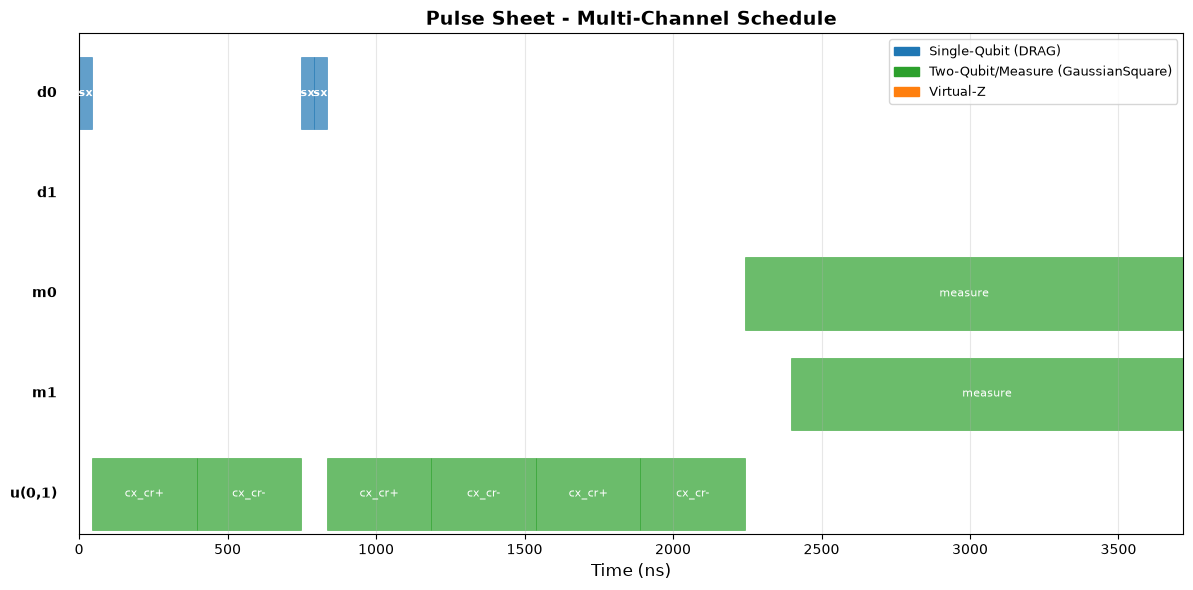

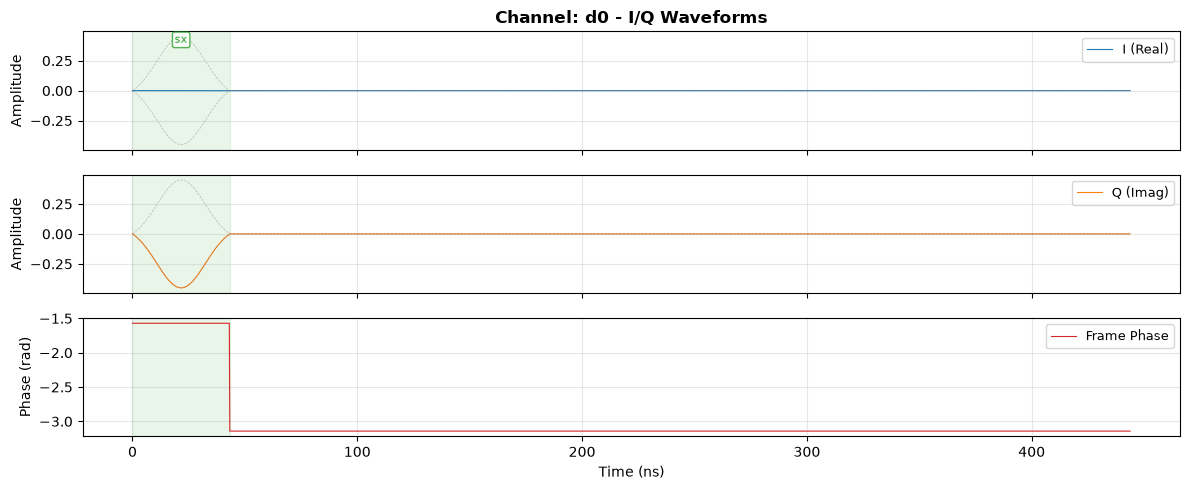

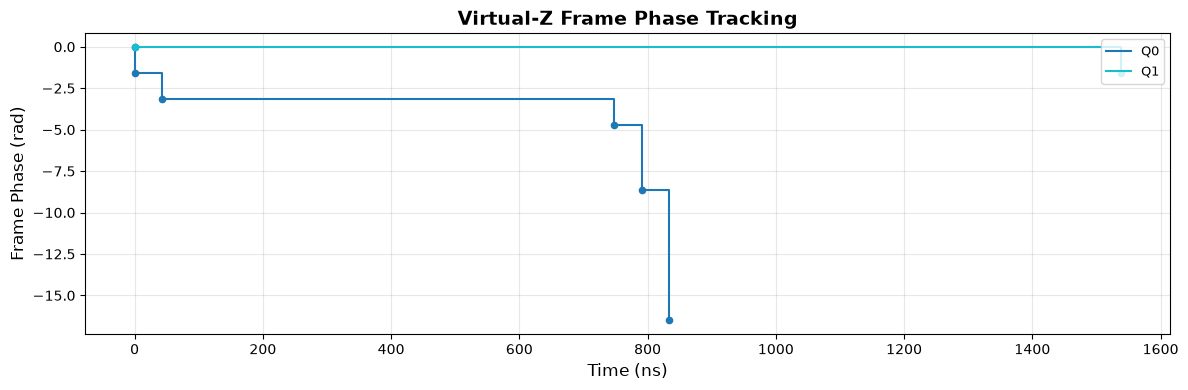

In [57]:
import matplotlib.pyplot as plt

from qiskit_waveform_sim.visualization import (
    plot_iq_waveforms,
    plot_phase_tracking,
    plot_pulse_sheet,
)

# Static pulse sheet
fig1 = plot_pulse_sheet(sim, figsize=(12, 6))
plt.show()

# Static I/Q waveforms
fig2 = plot_iq_waveforms(d0_snip, figsize=(12, 5))
plt.show()

# Static phase tracking
fig3 = plot_phase_tracking(sim, figsize=(12, 4))
plt.show()

## Summary

You've now seen the complete workflow:

1.  **Circuit â†’ Scheduled** using Qiskit 2.0 preset pass manager
2.  **Scheduled â†’ Compiled** with exact Virtual-Z frame tracking
3.  **Compiled â†’ Snippets** via lazy O(W) windowed evaluation
4.  **Visualization** with interactive Plotly and static Matplotlib

Next: Learn about custom pulse annotations in the :doc:`annotations` tutorial.